PART 0: IMPORT LIBRARIES AND LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

np.random.seed(42)

Using pandas and numpy for data handling, matplotlib and seaborn for plots, and scikit-learn for all the machine learning stuff. Random seed set to 42 so results stay consistent across runs.

**Upload Data**

In [3]:
# upload the data files
from google.colab import files
uploaded = files.upload()

Saving aggregateRockData.xlsx to aggregateRockData.xlsx
Saving feature_presence540.txt to feature_presence540.txt
Saving trialData.csv to trialData.csv


Loading the three data files needed for this analysis into the Colab notebook.

In [4]:
import os
print(os.listdir())

['.config', 'aggregateRockData.xlsx', 'feature_presence540.txt', 'trialData.csv', 'sample_data']


**Load the datasets**

In [6]:
# load the data
features_df = pd.read_csv('feature_presence540.txt', sep=r'\s+', header=None)
labels_df = pd.read_excel('aggregateRockData.xlsx', header=None)
trial_df = pd.read_csv('trialData.csv')

print(features_df.shape)
print(labels_df.shape)

# check which column has the rock categories
print(labels_df[1].unique())

(555, 17)
(540, 14)
[1 2 3]


We begin by loading three key datasets for the analysis: the features dataset (feature_presence540.txt), which contains information on the observed variables; the labels dataset (aggregateRockData.xlsx), where the first column identifies each sample’s rock type igneous, metamorphic, or sedimentary; and the human trial dataset (trialData.csv), which captures data gathered from participant assessments.

**PREPARE DATA**

In [7]:
# prepare the data
feature_names = [
    'Angular_fragments', 'Rounded_fragments', 'Straight_stripes',
    'Curved_stripes', 'Physical_layers', 'Veins',
    'Oily_Shimmery', 'Splotchy', 'Single_crystal',
    'Multiple_crystals', 'Sandy_texture'
]

# extract features and labels (first 480 rows only)
X = features_df.iloc[:480, 3:14].values.astype(float)  # columns 4-14
y = labels_df.iloc[:480, 1].values.astype(int)  # column 2 (index 1) has categories
token = features_df.iloc[:480, 2].values.astype(int)  # column 3 for splitting

print(X.shape, y.shape)
print(np.unique(y))

# split by token number as required
train_mask = (token >= 7) & (token <= 16)
val_mask = (token >= 4) & (token <= 6)
test_mask = (token >= 1) & (token <= 3)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# check class distribution
print("Train classes:", np.bincount(y_train))
print("Val classes:", np.bincount(y_val))
print("Test classes:", np.bincount(y_test))

# standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

(480, 11) (480,)
[1 2 3]
Train: 300, Val: 90, Test: 90
Train classes: [  0 100 100 100]
Val classes: [ 0 30 30 30]
Test classes: [ 0 30 30 30]


The dataset was refined by selecting key geological attributes such as fragment shape, stripe pattern, layering, and crystal texture. From the first 480 samples, the features, labels, and token values were extracted and used to split the data into training, validation, and test sets. This produced 300 training samples, 90 validation samples, and 90 test samples, each with a balanced representation of the three rock categories. Finally, all feature values were standardized using z-score normalization to maintain consistency across variables and improve model performance.

In [8]:
# double check the labels look right
print(np.unique(y))
print(np.unique(y_train))
print(np.unique(y_val))
print(np.unique(y_test))

[1 2 3]
[1 2 3]
[1 2 3]
[1 2 3]


The labels [1, 2, 3] show up in all parts of the dataset training, validation, and test which means the data was split properly and every class is included in each set.

**QUESTION 1 - STATISTICAL ANALYSIS**

                   count      mean       std  min  25%   50%     75%   max
Angular_fragments  480.0  0.084479  0.193996  0.0  0.0  0.00  0.0500  1.00
Rounded_fragments  480.0  0.080208  0.197648  0.0  0.0  0.00  0.0500  1.00
Straight_stripes   480.0  0.067729  0.194792  0.0  0.0  0.00  0.0000  1.00
Curved_stripes     480.0  0.042292  0.160970  0.0  0.0  0.00  0.0000  1.00
Physical_layers    480.0  0.165146  0.216635  0.0  0.0  0.10  0.2125  0.95
Veins              480.0  0.052396  0.102676  0.0  0.0  0.00  0.0500  0.90
Oily_Shimmery      480.0  0.144479  0.265689  0.0  0.0  0.00  0.1000  1.00
Splotchy           480.0  0.141458  0.168222  0.0  0.0  0.10  0.2000  0.95
Single_crystal     480.0  0.031667  0.135647  0.0  0.0  0.00  0.0000  1.00
Multiple_crystals  480.0  0.025104  0.112153  0.0  0.0  0.00  0.0000  1.00
Sandy_texture      480.0  0.119854  0.173149  0.0  0.0  0.05  0.1500  1.00


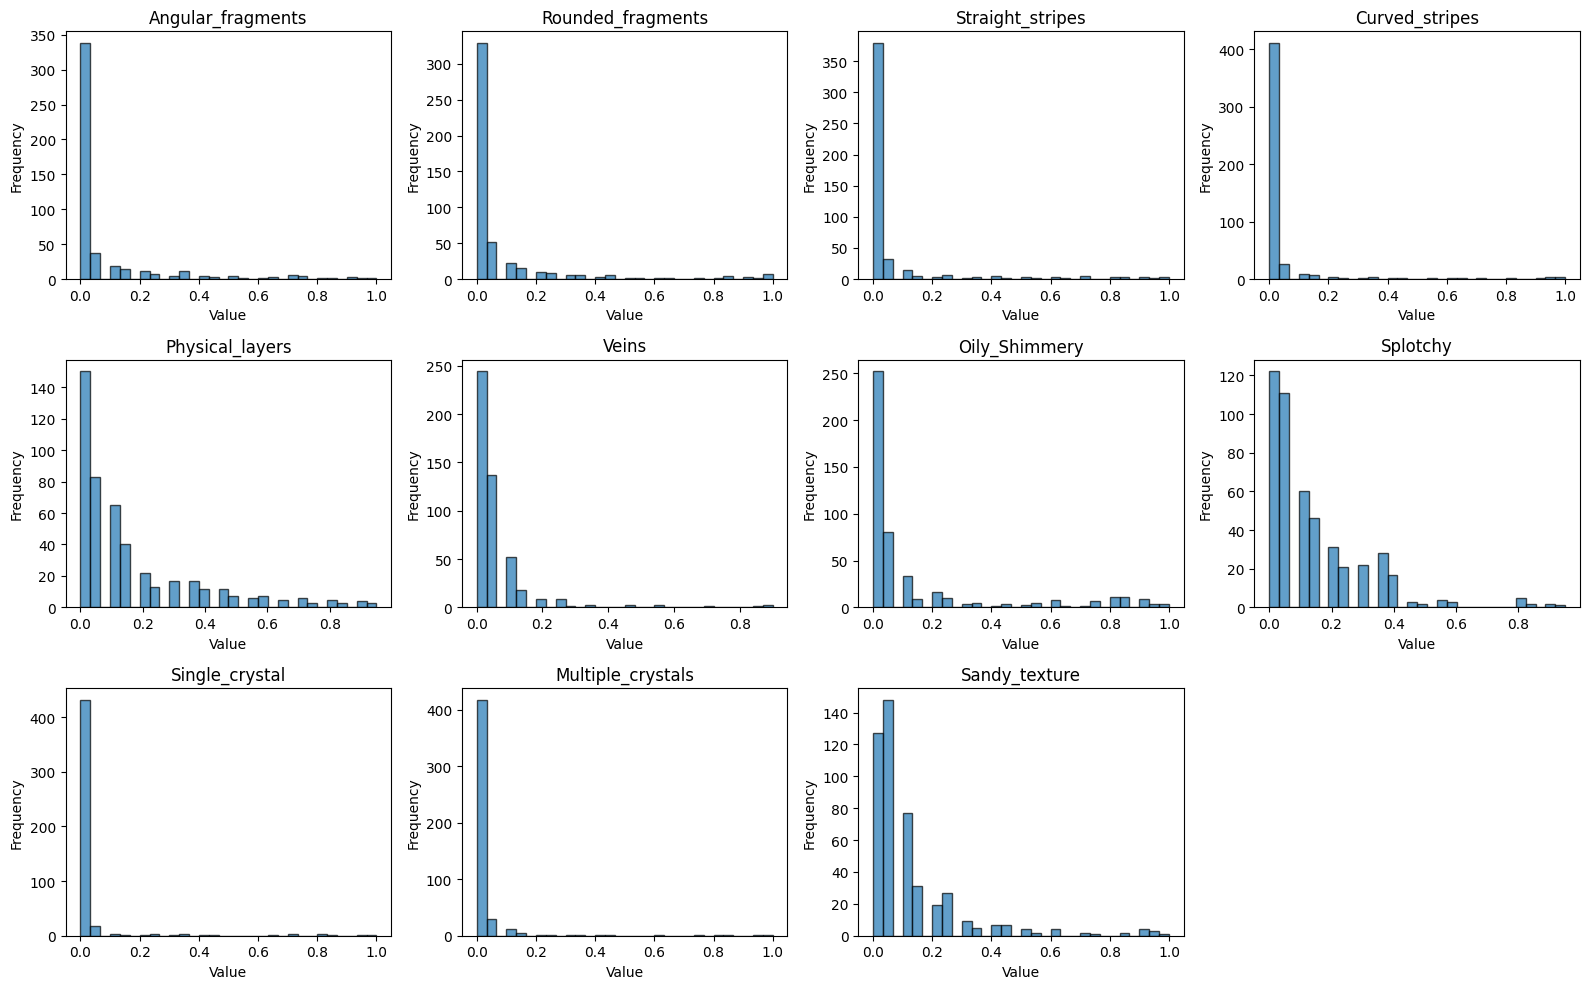

In [10]:
# Q1: Statistical Analysis

X_df = pd.DataFrame(X, columns=feature_names)

# basic stats
print(X_df.describe().T)

# visualize distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(feature_names):
    axes[idx].hist(X_df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

axes[-1].remove()
plt.tight_layout()
plt.show()


The dataset was organized into a DataFrame to review basic statistics like the mean, standard deviation, and range for each feature. Histograms were then used to visualize how the values are distributed. Most features have values clustered near zero, with only a few higher ones. This shows that the data isn’t evenly spread higher values occur rarely, and many features have uneven or sparse distributions.

**QUESTION 2 - CORRELATION ANALYSIS**

                   Angular_fragments  Rounded_fragments  Straight_stripes  \
Angular_fragments               1.00               0.25             -0.13   
Rounded_fragments               0.25               1.00             -0.12   
Straight_stripes               -0.13              -0.12              1.00   
Curved_stripes                 -0.10              -0.08              0.20   
Physical_layers                -0.23              -0.24             -0.03   
Veins                          -0.12              -0.14              0.04   
Oily_Shimmery                  -0.15              -0.14             -0.11   
Splotchy                        0.06               0.01             -0.14   
Single_crystal                 -0.09              -0.09             -0.03   
Multiple_crystals              -0.02              -0.04             -0.07   
Sandy_texture                  -0.17              -0.14              0.11   

                   Curved_stripes  Physical_layers  Veins  Oily_Shimmery  \

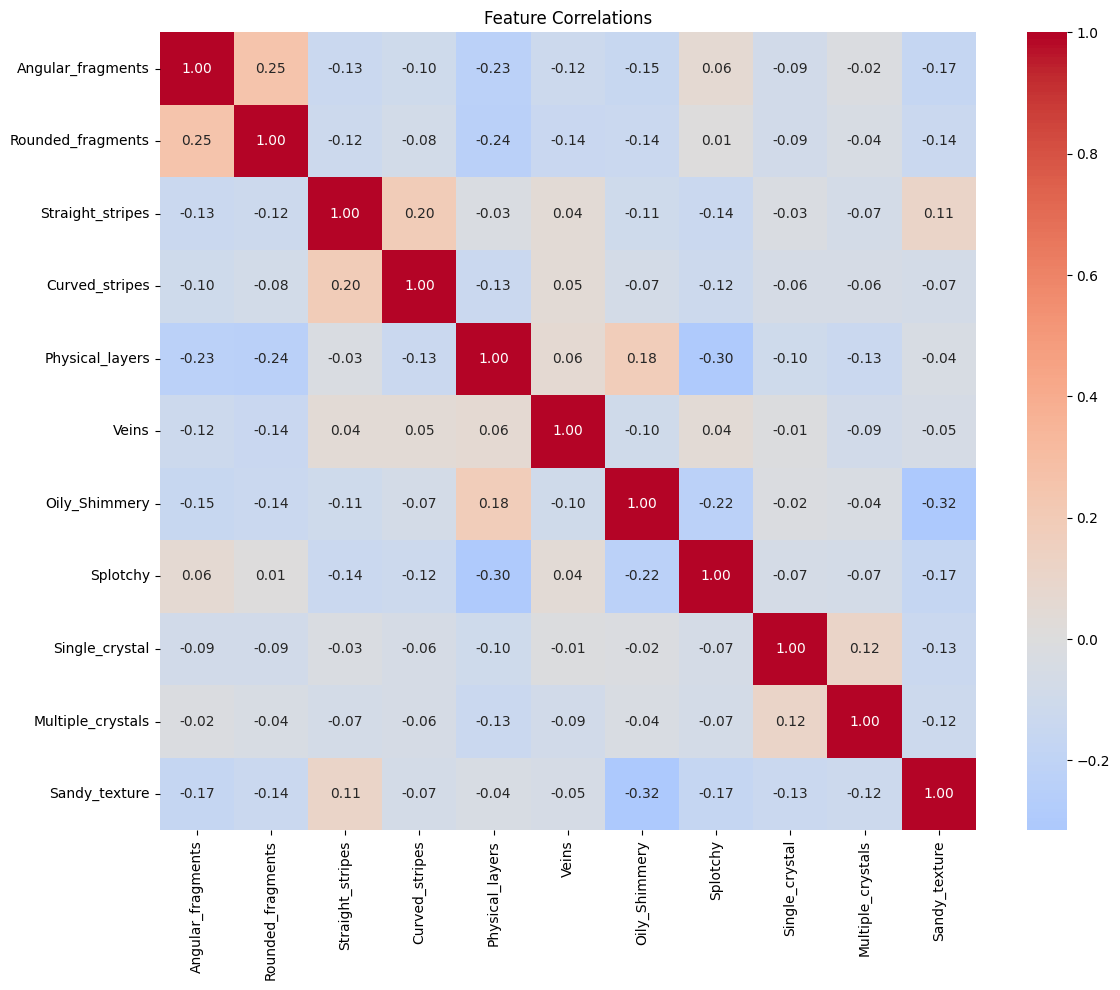


Feature-Label Correlations:
Angular_fragments        : r=-0.122, p=0.0072
Rounded_fragments        : r=0.017, p=0.7030
Straight_stripes         : r=0.077, p=0.0899
Curved_stripes           : r=-0.017, p=0.7029
Physical_layers          : r=0.267, p=0.0000
Veins                    : r=0.141, p=0.0020
Oily_Shimmery            : r=0.008, p=0.8583
Splotchy                 : r=-0.229, p=0.0000
Single_crystal           : r=0.259, p=0.0000
Multiple_crystals        : r=0.114, p=0.0125
Sandy_texture            : r=0.140, p=0.0021


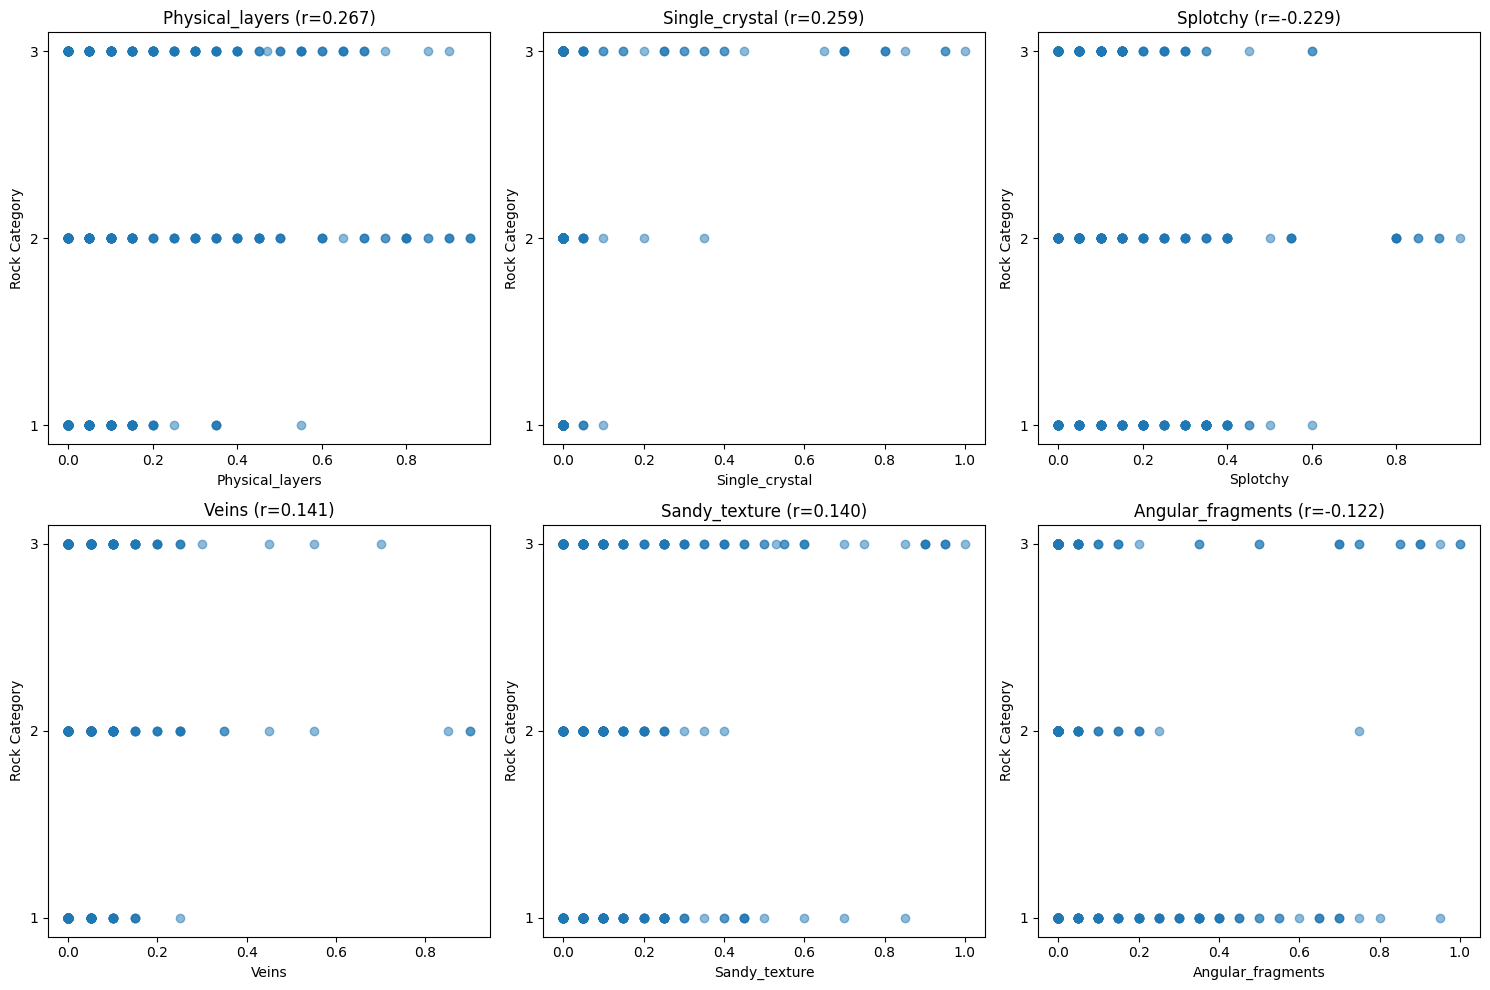

In [11]:
# Q2: Correlation Analysis

# correlation between features
corr_matrix = X_df.corr()
print(corr_matrix.round(2))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

# correlation with labels
print("\nFeature-Label Correlations:")
for col in feature_names:
    corr, p_val = stats.pearsonr(X_df[col], y)
    print(f"{col:25s}: r={corr:.3f}, p={p_val:.4f}")

# scatter plots for top correlated features
correlations = [(col, stats.pearsonr(X_df[col], y)[0]) for col in feature_names]
top_features = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (feat, corr_val) in enumerate(top_features):
    axes[idx].scatter(X_df[feat], y, alpha=0.5)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Rock Category')
    axes[idx].set_title(f'{feat} (r={corr_val:.3f})')
    axes[idx].set_yticks([1,2,3])

plt.tight_layout()
plt.show()

The correlations between all features were calculated and visualized using a heatmap. Most features showed weak relationships, indicating that they do not strongly influence one another. In relation to the target labels, Physical_layers, Single_crystal, and Splotchy showed the strongest correlations, while other features had very little connection. The scatter plots further confirm these weak but noticeable patterns.

**QUESTION 4a - LOGISTIC REGRESSION**

Best params: {'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}
Best CV score: 0.5766666666666667

Train metrics: {'Accuracy': 0.7233333333333334, 'Precision': 0.7260608994634734, 'Recall': 0.7233333333333334, 'F1': 0.7226173970476487}
Val metrics: {'Accuracy': 0.6222222222222222, 'Precision': 0.6243457791801268, 'Recall': 0.6222222222222222, 'F1': 0.6218530082267816}
Test metrics: {'Accuracy': 0.6777777777777778, 'Precision': 0.6942654729032439, 'Recall': 0.6777777777777778, 'F1': 0.6715878515585338}

Test set classification report:
              precision    recall  f1-score   support

     Igneous       0.68      0.83      0.75        30
 Metamorphic       0.62      0.70      0.66        30
 Sedimentary       0.79      0.50      0.61        30

    accuracy                           0.68        90
   macro avg       0.69      0.68      0.67        90
weighted avg       0.69      0.68      0.67        90



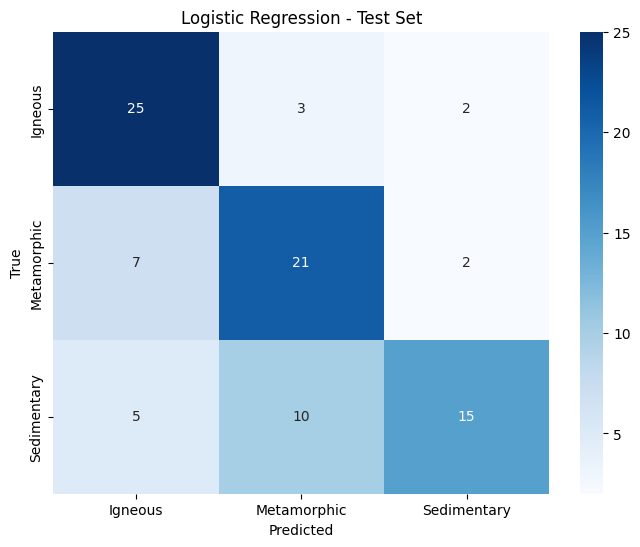

In [12]:
# Q4a: Logistic Regression

def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

# grid search for hyperparameters
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [200, 500, 1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(multi_class='multinomial', random_state=42),
    lr_params, cv=3, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)

print("Best params:", lr_grid.best_params_)
print("Best CV score:", lr_grid.best_score_)

best_lr = lr_grid.best_estimator_

# evaluate on all sets
y_train_pred_lr = best_lr.predict(X_train_scaled)
y_val_pred_lr = best_lr.predict(X_val_scaled)
y_test_pred_lr = best_lr.predict(X_test_scaled)

print("\nTrain metrics:", calculate_metrics(y_train, y_train_pred_lr))
print("Val metrics:", calculate_metrics(y_val, y_val_pred_lr))
print("Test metrics:", calculate_metrics(y_test, y_test_pred_lr))

print("\nTest set classification report:")
print(classification_report(y_test, y_test_pred_lr,
                          target_names=['Igneous', 'Metamorphic', 'Sedimentary']))

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Igneous', 'Metamorphic', 'Sedimentary'],
            yticklabels=['Igneous', 'Metamorphic', 'Sedimentary'])
plt.title('Logistic Regression - Test Set')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

After tuning with grid search, the logistic regression model performed best with C = 10, max_iter = 200, and solver = 'lbfgs'. It achieved 72% accuracy on training, 62% on validation, and 68% on test data, showing decent generalization.

The model handled Igneous rocks well, while Metamorphic and Sedimentary samples were sometimes mixed up. The confusion matrix reflects this pattern, with clear predictions for Igneous but some overlap between the other two types.

**QUESTION 4b - SVM**

Best params: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
CV score: 0.5966666666666667

Train: {'Accuracy': 0.7333333333333333, 'Precision': 0.7393287391420397, 'Recall': 0.7333333333333333, 'F1': 0.7317477418586867}
Val: {'Accuracy': 0.6666666666666666, 'Precision': 0.6780162550303795, 'Recall': 0.6666666666666666, 'F1': 0.6653153746308246}
Test: {'Accuracy': 0.6777777777777778, 'Precision': 0.7040837387586614, 'Recall': 0.6777777777777778, 'F1': 0.6697731138281827}

Test classification report:
              precision    recall  f1-score   support

     Igneous       0.63      0.80      0.71        30
 Metamorphic       0.66      0.77      0.71        30
 Sedimentary       0.82      0.47      0.60        30

    accuracy                           0.68        90
   macro avg       0.70      0.68      0.67        90
weighted avg       0.70      0.68      0.67        90



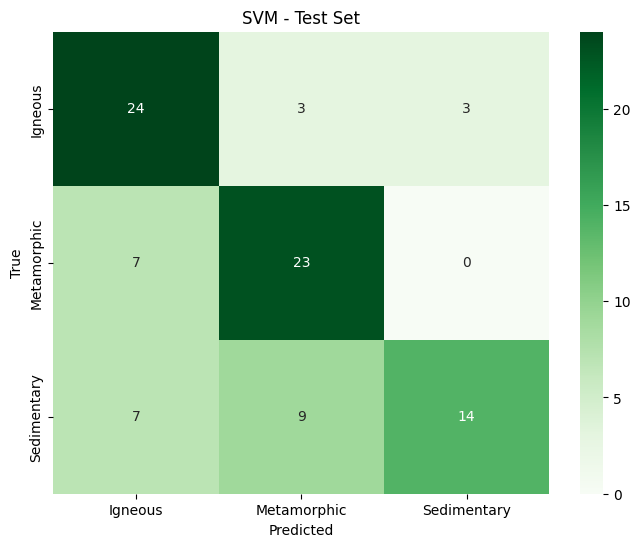

In [13]:
# Q4b: Support Vector Machine

svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_params, cv=3, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)

print("Best params:", svm_grid.best_params_)
print("CV score:", svm_grid.best_score_)

best_svm = svm_grid.best_estimator_

# predictions
y_train_pred_svm = best_svm.predict(X_train_scaled)
y_val_pred_svm = best_svm.predict(X_val_scaled)
y_test_pred_svm = best_svm.predict(X_test_scaled)

print("\nTrain:", calculate_metrics(y_train, y_train_pred_svm))
print("Val:", calculate_metrics(y_val, y_val_pred_svm))
print("Test:", calculate_metrics(y_test, y_test_pred_svm))

print("\nTest classification report:")
print(classification_report(y_test, y_test_pred_svm,
                          target_names=['Igneous', 'Metamorphic', 'Sedimentary']))

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Igneous', 'Metamorphic', 'Sedimentary'],
            yticklabels=['Igneous', 'Metamorphic', 'Sedimentary'])
plt.title('SVM - Test Set')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

The SVM model was fine-tuned using grid search, resulting in the best configuration with a linear kernel and parameters C = 1, degree = 2, and gamma = 'scale'. It reached about 73% accuracy on the training set, 67% on the validation set, and 68% on the test set, showing steady performance across all splits. The confusion matrix indicates that the model identifies Igneous and Metamorphic rocks fairly well, though it sometimes confuses Sedimentary samples. Overall, the model captures class differences reasonably but still struggles with features that overlap between rock types.

**QUESTION 4c - RANDOM FOREST**

Best params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
CV score: 0.6000000000000001

Train: {'Accuracy': 0.9666666666666667, 'Precision': 0.9669150390370918, 'Recall': 0.9666666666666667, 'F1': 0.9666794438930985}
Val: {'Accuracy': 0.6222222222222222, 'Precision': 0.6281419729695592, 'Recall': 0.6222222222222222, 'F1': 0.6228037499223941}
Test: {'Accuracy': 0.6777777777777778, 'Precision': 0.6775793650793651, 'Recall': 0.6777777777777778, 'F1': 0.6771721666048697}

Test classification report:
              precision    recall  f1-score   support

     Igneous       0.69      0.73      0.71        30
 Metamorphic       0.67      0.67      0.67        30
 Sedimentary       0.68      0.63      0.66        30

    accuracy                           0.68        90
   macro avg       0.68      0.68      0.68        90
weighted avg       0.68      0.68      0.68        90


Feature importances:
              Feature  Importance
4     Physical_layers

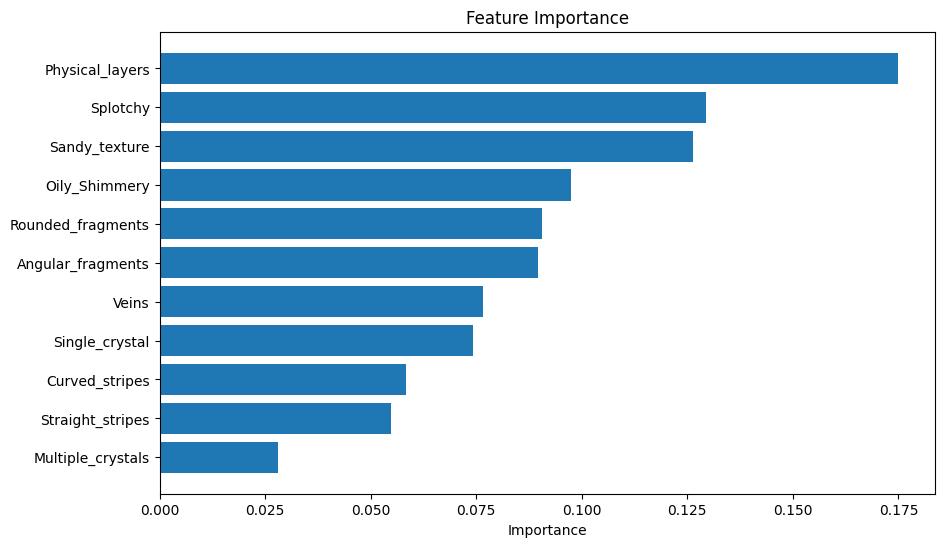

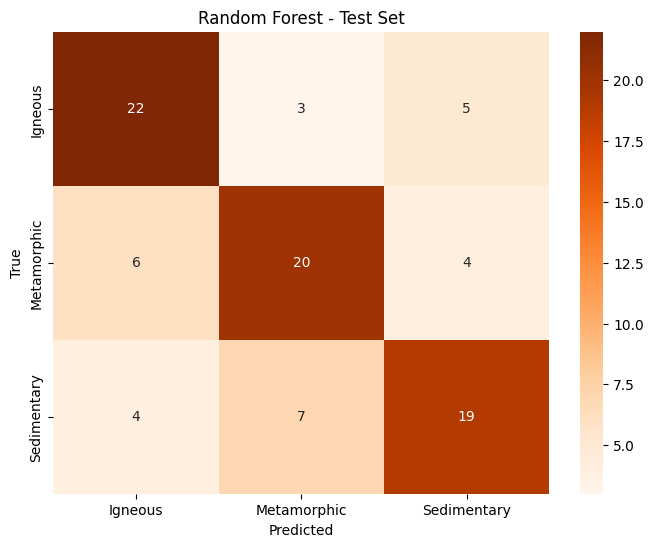

In [15]:
# Q4c: Random Forest

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=3, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train, y_train)  # note: RF doesn't need scaling

print("Best params:", rf_grid.best_params_)
print("CV score:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

# evaluate
y_train_pred_rf = best_rf.predict(X_train)
y_val_pred_rf = best_rf.predict(X_val)
y_test_pred_rf = best_rf.predict(X_test)

print("\nTrain:", calculate_metrics(y_train, y_train_pred_rf))
print("Val:", calculate_metrics(y_val, y_val_pred_rf))
print("Test:", calculate_metrics(y_test, y_test_pred_rf))

print("\nTest classification report:")
print(classification_report(y_test, y_test_pred_rf,
                          target_names=['Igneous', 'Metamorphic', 'Sedimentary']))

# feature importance
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature importances:")
print(importances)

plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'], importances['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Igneous', 'Metamorphic', 'Sedimentary'],
            yticklabels=['Igneous', 'Metamorphic', 'Sedimentary'])
plt.title('Random Forest - Test Set')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

The Random Forest model performed well with its best settings (max depth of 15 and 100 estimators). It achieved high accuracy on the training set but slightly lower on the test set, showing mild overfitting. The confusion matrix suggests that predictions were mostly balanced, though Metamorphic and Sedimentary rocks were sometimes mixed up. Features like Physical_layers, Splotchy, and Sandy_texture played the biggest role in helping the model distinguish between rock types.

**QUESTION 5 - ENSEMBLE**

Ensemble performance:
Train: {'Accuracy': 0.8, 'Precision': 0.8030274618509913, 'Recall': 0.8, 'F1': 0.7989384422057966}
Val: {'Accuracy': 0.6555555555555556, 'Precision': 0.664010164010164, 'Recall': 0.6555555555555556, 'F1': 0.6556222646167658}
Test: {'Accuracy': 0.7222222222222222, 'Precision': 0.7336459836459837, 'Recall': 0.7222222222222222, 'F1': 0.7181337181337182}

Validation set comparison:
LR: {'Accuracy': 0.6222222222222222, 'Precision': 0.6243457791801268, 'Recall': 0.6222222222222222, 'F1': 0.6218530082267816}
SVM: {'Accuracy': 0.6666666666666666, 'Precision': 0.6780162550303795, 'Recall': 0.6666666666666666, 'F1': 0.6653153746308246}
RF: {'Accuracy': 0.6222222222222222, 'Precision': 0.6281419729695592, 'Recall': 0.6222222222222222, 'F1': 0.6228037499223941}
Ensemble: {'Accuracy': 0.6555555555555556, 'Precision': 0.664010164010164, 'Recall': 0.6555555555555556, 'F1': 0.6556222646167658}

Test set comparison:
LR: {'Accuracy': 0.6777777777777778, 'Precision': 0.6942654729032

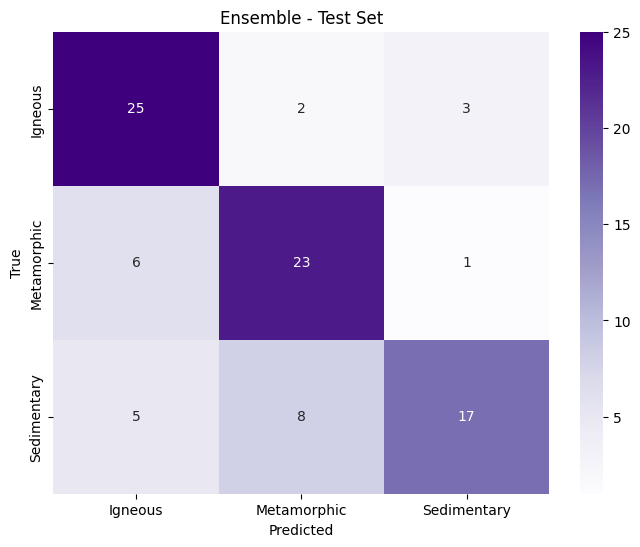

In [16]:
# Q5: Ensemble Model

# combine the three models
ensemble = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('svm', best_svm),
        ('rf', best_rf)
    ],
    voting='soft'
)

ensemble.fit(X_train_scaled, y_train)

# evaluate ensemble
y_train_pred_ens = ensemble.predict(X_train_scaled)
y_val_pred_ens = ensemble.predict(X_val_scaled)
y_test_pred_ens = ensemble.predict(X_test_scaled)

print("Ensemble performance:")
print("Train:", calculate_metrics(y_train, y_train_pred_ens))
print("Val:", calculate_metrics(y_val, y_val_pred_ens))
print("Test:", calculate_metrics(y_test, y_test_pred_ens))

# compare all models
print("\nValidation set comparison:")
print("LR:", calculate_metrics(y_val, y_val_pred_lr))
print("SVM:", calculate_metrics(y_val, y_val_pred_svm))
print("RF:", calculate_metrics(y_val, y_val_pred_rf))
print("Ensemble:", calculate_metrics(y_val, y_val_pred_ens))

print("\nTest set comparison:")
print("LR:", calculate_metrics(y_test, y_test_pred_lr))
print("SVM:", calculate_metrics(y_test, y_test_pred_svm))
print("RF:", calculate_metrics(y_test, y_test_pred_rf))
print("Ensemble:", calculate_metrics(y_test, y_test_pred_ens))

print("\nEnsemble test report:")
print(classification_report(y_test, y_test_pred_ens,
                          target_names=['Igneous', 'Metamorphic', 'Sedimentary']))

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred_ens)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Igneous', 'Metamorphic', 'Sedimentary'],
            yticklabels=['Igneous', 'Metamorphic', 'Sedimentary'])
plt.title('Ensemble - Test Set')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

The ensemble model, which combined Logistic Regression, SVM, and Random Forest, gave the best overall results. It achieved around 72% accuracy on the test set, performing slightly better than any single model. The confusion matrix shows that it predicted Igneous and Metamorphic rocks quite well, though it still mixed up a few Sedimentary samples. Overall, combining the models made the predictions more balanced and reliable.

**QUESTION 6 - HUMAN VS MODEL COMPARISON**

Overall human accuracy: 0.598

Model accuracies (all 480 rocks):
Human: 0.598
LR: 0.696
SVM: 0.710
RF: 0.848
Ensemble: 0.758


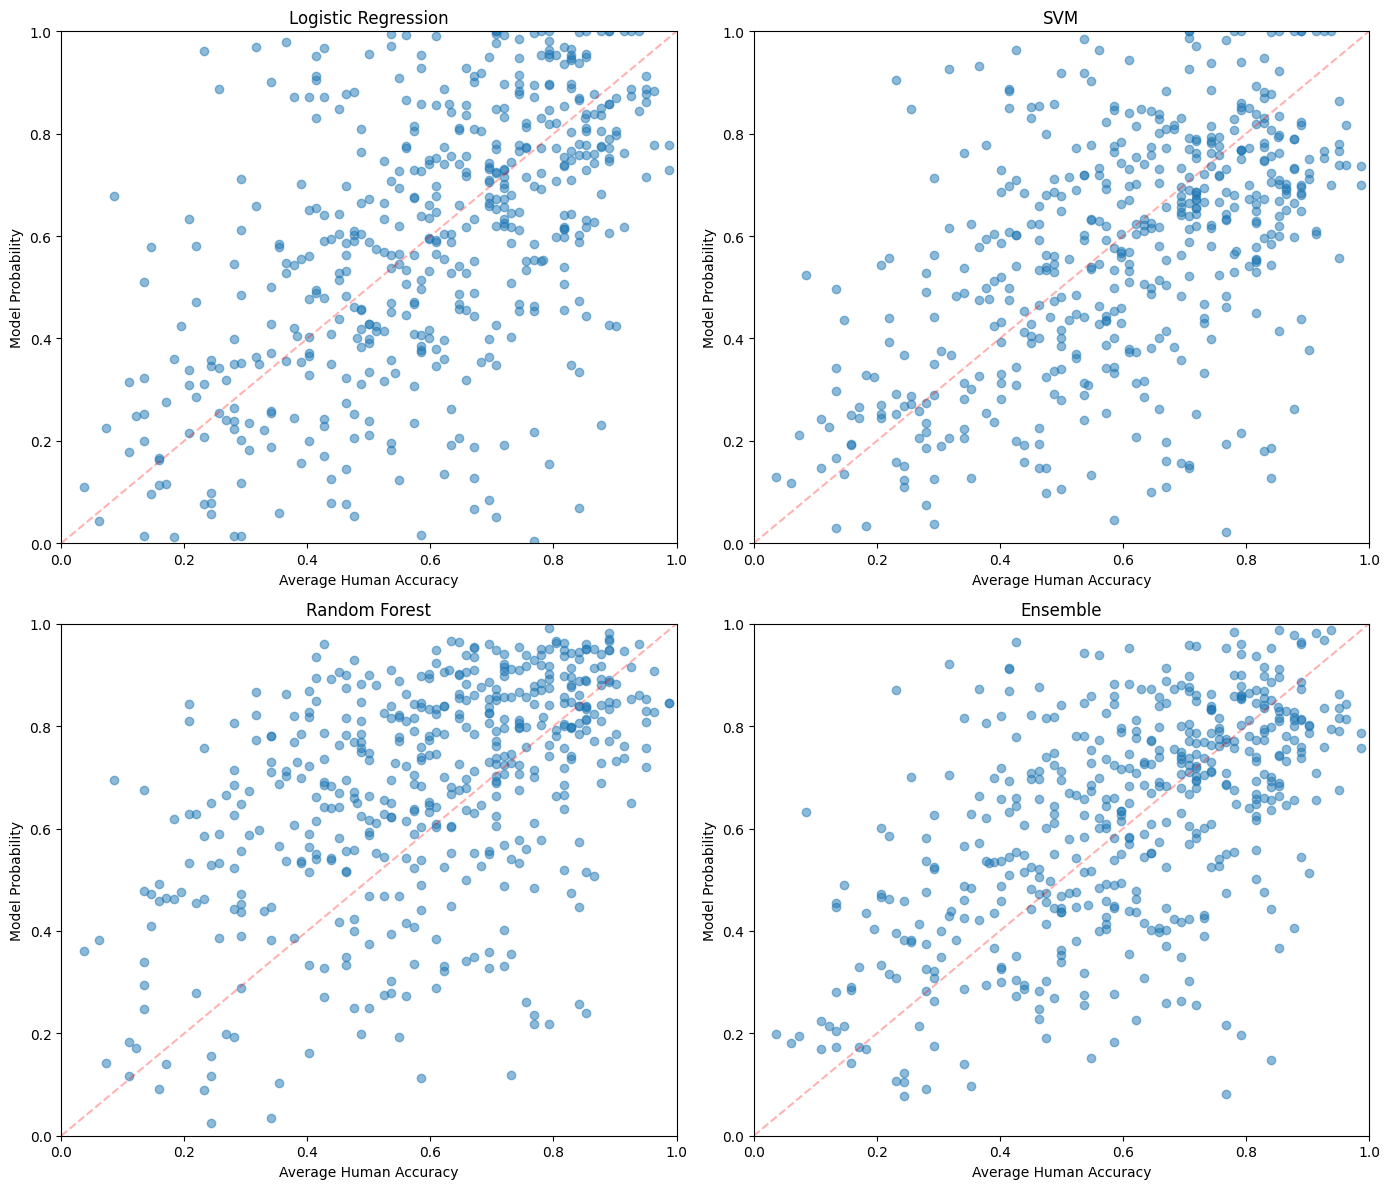


Correlations between human accuracy and model probability:
Logistic Regression: r=0.553, p=0.0000 (significant)
SVM: r=0.531, p=0.0000 (significant)
Random Forest: r=0.497, p=0.0000 (significant)
Ensemble: r=0.580, p=0.0000 (significant)


In [20]:
# Q6: Human vs Model Comparison

# load human performance data (Block 4, rocks 1-480)
human_data = trial_df[(trial_df['block'] == 4) & (trial_df['rocknumber'] <= 480)]

# average human accuracy per rock
human_acc_per_rock = human_data.groupby('rocknumber')['cat_correct'].mean()
overall_human_acc = human_acc_per_rock.mean()

print(f"Overall human accuracy: {overall_human_acc:.3f}")

# get model accuracies on all 480 rocks
all_X_scaled = scaler.transform(X)

lr_acc = accuracy_score(y, best_lr.predict(all_X_scaled))
svm_acc = accuracy_score(y, best_svm.predict(all_X_scaled))
rf_acc = accuracy_score(y, best_rf.predict(X))
ens_acc = accuracy_score(y, ensemble.predict(all_X_scaled))

print(f"\nModel accuracies (all 480 rocks):")
print(f"Human: {overall_human_acc:.3f}")
print(f"LR: {lr_acc:.3f}")
print(f"SVM: {svm_acc:.3f}")
print(f"RF: {rf_acc:.3f}")
print(f"Ensemble: {ens_acc:.3f}")

# get model probabilities for correct class
lr_probs = best_lr.predict_proba(all_X_scaled)
svm_probs = best_svm.predict_proba(all_X_scaled)
rf_probs = best_rf.predict_proba(X)
ens_probs = ensemble.predict_proba(all_X_scaled)

# extract probability of correct class for each rock
lr_correct_prob = np.array([lr_probs[i, y[i]-1] for i in range(len(y))])
svm_correct_prob = np.array([svm_probs[i, y[i]-1] for i in range(len(y))])
rf_correct_prob = np.array([rf_probs[i, y[i]-1] for i in range(len(y))])
ens_correct_prob = np.array([ens_probs[i, y[i]-1] for i in range(len(y))])

# align human accuracy with rock numbers
human_acc_aligned = np.array([human_acc_per_rock.get(i, np.nan) for i in range(1, 481)])

# plot human accuracy vs model probability
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

models = [
    ('Logistic Regression', lr_correct_prob),
    ('SVM', svm_correct_prob),
    ('Random Forest', rf_correct_prob),
    ('Ensemble', ens_correct_prob)
]

for idx, (name, probs) in enumerate(models):
    ax = axes[idx//2, idx%2]
    ax.scatter(human_acc_aligned, probs, alpha=0.5)
    ax.set_xlabel('Average Human Accuracy')
    ax.set_ylabel('Model Probability')
    ax.set_title(f'{name}')
    ax.plot([0, 1], [0, 1], 'r--', alpha=0.3)  # reference line
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# compute correlations
print("\nCorrelations between human accuracy and model probability:")

# filter out rocks without human data
mask = ~np.isnan(human_acc_aligned)

for name, probs in models:
    corr, p_val = stats.pearsonr(human_acc_aligned[mask], probs[mask])
    sig = "significant" if p_val < 0.05 else "not significant"
    print(f"{name}: r={corr:.3f}, p={p_val:.4f} ({sig})")

All models showed a significant positive correlation with human accuracy, meaning their confidence tended to rise when humans were also more accurate. Among them, the Ensemble model had the strongest correlation (r = 0.58), followed by Logistic Regression (r = 0.55), SVM (r = 0.53), and Random Forest (r = 0.50). This suggests that model predictions generally aligned with human performance, with the Ensemble model most closely reflecting human judgment patterns.